In [ ]:
from __future__ import annotations
from tqdm import tqdm
import argparse
from pathlib import Path
import time
import pickle
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

In [11]:
# build transmon hamiltonian
# truncate charge spapace to have 31 basis states
def transmon_hamiltonian(EJ, EC, ng=0.0, charge_trunc=15):
    dim = 2 * charge_trunc + 1
    ns = np.arange(-charge_trunc, charge_trunc + 1, dtype=float)
    H_C = qt.qdiags(4 * EC * (ns - ng) ** 2, 0)
    H_J = qt.qdiags(np.ones(dim - 1), 1) + qt.qdiags(np.ones(dim - 1), -1)
    return H_C - 0.5 * EJ * H_J, ns

# build full system hamiltonian
def build_dynamics_hamiltonian(args):
    H_tmon_charge, ns = transmon_hamiltonian(
        args.EJ, args.EC, ng=args.ng, charge_trunc=args.charge_trunc
    )
    tmon_evals_full, tmon_evecs_full = H_tmon_charge.eigenstates()
    tmon_evals_full = np.array(tmon_evals_full)
    tmon_evals_full -= tmon_evals_full[0]

    # diagonalize transmon in charge hamiltonian
    n_charge = qt.qdiags(ns - args.ng, 0)
    U = qt.Qobj(
        np.column_stack(
            [tmon_evecs_full[i].full()[:, 0] for i in range(args.tmon_levels)]
        ),
        dims=[[2 * args.charge_trunc + 1], [args.tmon_levels]],
    )
    n_t  = U.dag() * n_charge * U

    # get charge operator in transmon egienstate basis
    H_t  = qt.qdiags(tmon_evals_full[: args.tmon_levels], 0)

    a        = qt.destroy(args.cav_trunc) # resonator lowering operator in Fock space truncated by cavituy
    I_t      = qt.qeye(args.tmon_levels) # project onto full transmon \prod resonator Hilbert space
    a_full   = qt.tensor(I_t, a)
    num_full = a_full.dag() * a_full

    # hamiltonian in terms of cycles 
    H0_cycles = (
        qt.tensor(H_t, qt.qeye(args.cav_trunc)) # transmon energy
        + args.wr * qt.tensor(I_t, a.dag() * a) # resonator energy
        - 1j * args.g * qt.tensor(n_t, a - a.dag()) # coupling
    )
    H0 = 2 * np.pi * H0_cycles
    # convert from GHz to rad/ns
    eps_d  = 2 * np.pi * args.eps_d_over_2pi
    wd     = 2 * np.pi * args.wd_over_2pi
    kappa  = 2 * np.pi * args.kappa_over_2pi

    H_drive = -1j * eps_d * (a_full - a_full.dag())
    # define microwave drive
    def drive_coeff(t, args=None):
        return np.sin(wd * t)

    H     = [H0, [H_drive, drive_coeff]]
    c_ops = [np.sqrt(kappa) * a_full]

    return {
        "H":          H,
        "H0_cycles":  H0_cycles,
        "c_ops":      c_ops,
        "num_full":   num_full,
        "I_t":        I_t,
        "kappa":      kappa,
    }


# label branches
def relabel_dressed_branches(H0_cycles, args):
    dim = args.tmon_levels * args.cav_trunc
    print(f"Diagonalizing Hamiltonian (dim={dim})...")
    t0 = time.time()
    dressed_evals, dressed_evecs = H0_cycles.eigenstates()
    print(f"  Done in {time.time()-t0:.1f}s")
    # get bare eigenstates
    bare_eigenstates = [
        qt.tensor(qt.basis(args.tmon_levels, i), qt.basis(args.cav_trunc, n))
        for i in range(args.tmon_levels)
        for n in range(args.cav_trunc)
    ]
    create_op        = qt.tensor(qt.qeye(args.tmon_levels), qt.create(args.cav_trunc))
    relabeled_states = []
    relabeled_indices = []
    assigned         = np.zeros(dim)

    print("Relabeling branches...")
    # add a photon to the resonator
    for i in tqdm(range(args.tmon_levels), desc="Relabeling branches"):
        for n in range(args.cav_trunc):
            if n == 0:
                compare = bare_eigenstates[i * args.cav_trunc]
            else:
                compare = (create_op * relabeled_states[i * args.cav_trunc + (n - 1)]).unit()

            cur_overlap, cur_state = -1.0, -1
            for k in range(dim):
                if assigned[k] == 0:
                    ov = abs(dressed_evecs[k].overlap(compare)) ** 2
                    if ov > cur_overlap:
                        cur_overlap, cur_state = ov, k

            assigned[cur_state] = 1
            relabeled_indices.append(cur_state)
            relabeled_states.append(dressed_evecs[cur_state])

    return np.array(dressed_evals), relabeled_states, np.array(relabeled_indices, dtype=int)


In [ ]:
# use monte carlo wave function solver to get quantum trajectories
# runs ntraj independent stochastic trajectories under the effective hamiltonian
# and at random times from the photon emission probability, apply the collapse operator (one photon lost)
# average over many trajectories to get the same result as the Lindblad master equation but store trajectories rather
# than full density matrices
# to be more efficent, store full state vector at every time for each trajectory, then post process
def run_mcsolve(built, relabeled_states, args):
    t_final = args.kappa_t_final / built["kappa"]
    tlist   = np.linspace(0, t_final, args.num_times)
    psi0    = relabeled_states[args.initial_branch * args.cav_trunc + args.initial_fock]

    print(
        f"Running mcsolve: {args.tmon_levels} tmon levels, "
        f"{args.cav_trunc} cav states, {args.ntraj} trajectories, "
        f"{args.num_times} time points..."
    )
    result = qt.mcsolve(
        built["H"],
        psi0,
        tlist,
        built["c_ops"],
        e_ops=[],
        ntraj=args.ntraj,
        options={"store_states": True, "progress_bar": "enhanced"},
    )
    return result, tlist


# save result so that long solving does not need to be rerun 
def save_result(result, tlist, path):
    """Pickle the full mcsolve result so it can be reloaded without rerunning."""
    path = Path(path)
    with open(path, "wb") as f:
        pickle.dump({"result": result, "tlist": tlist}, f)
    print(f"mcsolve result saved to {path.resolve()}")


In [ ]:
# load back information
def load_result(path):
    path = Path(path)
    with open(path, "rb") as f:
        d = pickle.load(f)
    print(f"mcsolve result loaded from {path.resolve()}")
    return d["result"], d["tlist"]

# post processing 
def to_vec(state):
    """Extract 1D numpy array from either a Qobj ket or a raw numpy array."""
    if hasattr(state, "full"):
        return state.full()[:, 0]
    return np.asarray(state).flatten()

# for each branch, stack all dressed states to compute overlap of branch
def post_process(result, tlist, built, relabeled_states, args):
    print("Post-processing trajectories...")
    n_times   = len(tlist)
    n_branches = len(args.highlight_branches)

    # pre-build branch state matrices: shape (dim, cav_trunc) each
    branch_state_arrays = {
        branch: np.column_stack([
            relabeled_states[branch * args.cav_trunc + n].full()[:, 0]
            for n in range(args.cav_trunc)
        ])
        for branch in args.highlight_branches
    }
    num_mat = built["num_full"].full()

    Nr_t                  = np.zeros(n_times)
    branch_population_array = np.zeros((n_branches, n_times))
    final_fock_distribution = np.zeros(args.cav_trunc)

    for traj_states in tqdm(result.states, desc="Trajectories"):
        for t_idx, state in enumerate(traj_states):
            vec = to_vec(state)
            Nr_t[t_idx] += np.real(vec.conj() @ num_mat @ vec)
            for b_idx, branch in enumerate(args.highlight_branches):
                overlaps = branch_state_arrays[branch].conj().T @ vec
                branch_population_array[b_idx, t_idx] += np.real(
                    np.sum(np.abs(overlaps) ** 2)
                )

        final_vec     = to_vec(traj_states[-1])
        final_reshaped = final_vec.reshape(args.tmon_levels, args.cav_trunc)
        final_fock_distribution += np.sum(np.abs(final_reshaped) ** 2, axis=0)

    Nr_t                    /= args.ntraj
    branch_population_array /= args.ntraj
    final_fock_distribution /= args.ntraj
    kappa_t                  = built["kappa"] * tlist

    return {
        "kappa_t":                kappa_t,
        "Nr_t":                   Nr_t,
        "highlight_branches":     np.array(args.highlight_branches, dtype=int),
        "branch_population_array": branch_population_array,
        "fock_numbers":           np.arange(args.cav_trunc),
        "final_fock_distribution": final_fock_distribution,
    }

# save post-processed trajectories
def save_data(data, path):
    np.savez(Path(path), **data)
    print(f"Post-processed data saved to {Path(path).resolve()}")




In [ ]:
def load_data(path):
    with np.load(Path(path)) as f:
        return {k: f[k] for k in f.files}


# plotting 
def plot_data(data, output=None):
    highlight_colors = {0: "blue", 1: "red", 7: "green", 10: "orange", 11: "pink"}

    kappa_t              = data["kappa_t"]
    Nr_t                 = data["Nr_t"]
    branches             = data["highlight_branches"].astype(int)
    branch_populations   = data["branch_population_array"]
    fock_numbers         = data["fock_numbers"]
    final_fock_dist      = data["final_fock_distribution"]

    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    for idx, branch in enumerate(branches):
        ax.plot(
            kappa_t,
            np.maximum(branch_populations[idx], 1e-15),
            color=highlight_colors.get(int(branch), "gray"),
            label=rf"${int(branch)}_t$",
        )
    ax.set_yscale("log")
    ax.set_ylim(1e-3, 1.1)
    ax.set_xlim(0, kappa_t[-1])
    ax.set_xlabel(r"$\kappa t$")
    ax.set_ylabel(r"$P(B_{i_t})$")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    tick_kt = np.linspace(0, kappa_t[-1], 5)
    ax_top.set_xticks(tick_kt)
    ax_top.set_xticklabels([f"{x:.0f}" for x in np.interp(tick_kt, kappa_t, Nr_t)])
    ax_top.set_xlabel(r"$\langle N_r\rangle(t)$")

    inset = ax.inset_axes([0.17, 0.48, 0.34, 0.34])
    inset.plot(fock_numbers, np.maximum(final_fock_dist, 1e-15), color="black")
    inset.set_yscale("log")
    inset.set_xlim(0, max(fock_numbers))
    inset.set_ylim(1e-5, 1)
    inset.set_xlabel(r"$n_r$", fontsize=9)
    inset.set_ylabel(r"$P(n_r)$", fontsize=9)
    inset.tick_params(labelsize=8)

    fig.tight_layout()
    if output:
        fig.savefig(output, dpi=200)
        print(f"Plot saved to {Path(output).resolve()}")
    else:
        plt.show()


# make changes to args for ease of running trajectories

def make_args(**overrides):
    """
    Build the args namespace directly (no argparse) so this works in a notebook.
    Override any parameter by passing it as a keyword argument.
    """
    import types
    defaults = dict(
        EC               = 0.22,
        EJ               = None,       # set to 110*EC below if None
        ng               = 0.0,
        charge_trunc     = 15,
        wr               = 7.5,
        g                = 0.120,
        tmon_levels      = 16,
        cav_trunc        = 60,
        ntraj            = 50,
        num_times        = 301,
        kappa_t_final    = 2.0,
        eps_d_over_2pi   = 0.180,
        wd_over_2pi      = 7.515,
        kappa_over_2pi   = 0.00795,
        initial_branch   = 1,
        initial_fock     = 0,
        highlight_branches = [0, 1, 7, 10, 11],
        out              = Path("fig2c_full_data.npz"),
        result_path      = Path("fig2c_mcsolve_result.pkl"),
    )
    defaults.update(overrides)
    args = types.SimpleNamespace(**defaults)
    if args.EJ is None:
        args.EJ = 110 * args.EC
    return args




In [2]:
# Fig. 2(c) total run: build, run, post-process, save
# don't run if you just want to see graphs, use pre-loaded info below
args  = make_args()   # paper defaults: 16 tmon levels, 60 cav states, 50 traj
built = build_dynamics_hamiltonian(args)
dressed_evals, relabeled_states, relabeled_indices = relabel_dressed_branches(
    built["H0_cycles"], args
)

result, tlist = run_mcsolve(built, relabeled_states, args)
save_result(result, tlist, args.result_path)   # saves to fig2c_mcsolve_result.pkl

data = post_process(result, tlist, built, relabeled_states, args)
save_data(data, args.out)                       # saves to fig2c_full_data.npz


Diagonalizing Hamiltonian (dim=960)...
  Done in 0.3s
Relabeling branches...


Relabeling branches: 100%|██████████| 16/16 [00:02<00:00,  7.75it/s]

Running mcsolve: 16 tmon levels, 60 cav states, 50 trajectories, 301 time points...
 [          2%           ] Elapsed 0.00s / Remaining 00:00:00:00

KeyboardInterrupt: 

mcsolve result loaded from /home/yz0814/fig2c_mcsolve_result.pkl


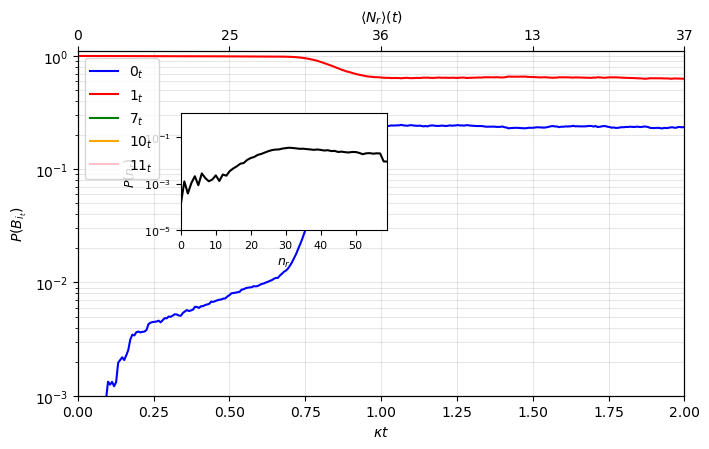

In [6]:
# ── Fig. 2(c) — plot (reload from disk if needed) ────────────────────────────
result, tlist = load_result("/home/yz0814/fig2c_mcsolve_result.pkl") # replace with appropriate path
data = load_data("/home/yz0814/fig2c_full_data.npz") # replace with appropriate path
plot_data(data)

In [ ]:
# Fig. 3(h) — build, run, post-process, save
args_pos = make_args(
    EC             = 0.22,
    EJ             = 24.2,
    wr             = 5.300,
    wd_over_2pi    = 5.267,
    eps_d_over_2pi = 0.093,
    g              = 0.120,
    kappa_over_2pi = 0.01198,
    cav_trunc      = 30,
    tmon_levels    = 20,
    ntraj          = 50,
    num_times      = 301,
    kappa_t_final  = 4.0,
    initial_branch = 1,
    initial_fock   = 0,
    highlight_branches = list(range(20)),
    out            = Path("fig3h_data.npz"),
    result_path    = Path("fig3h_mcsolve_result.pkl"),
)

built_pos = build_dynamics_hamiltonian(args_pos)
_, relabeled_states_pos, _ = relabel_dressed_branches(built_pos["H0_cycles"], args_pos)

result_pos, tlist_pos = run_mcsolve(built_pos, relabeled_states_pos, args_pos)
save_result(result_pos, tlist_pos, args_pos.result_path)

data_pos = post_process(result_pos, tlist_pos, built_pos, relabeled_states_pos, args_pos)
save_data(data_pos, args_pos.out)


In [12]:
def plot_fig3h(data, Nr_max=10, t_cut=None):
    Nr_t               = data["Nr_t"]
    branches           = data["highlight_branches"].astype(int)
    branch_populations = data["branch_population_array"]
    branch_color       = {1: "#C62828", 7: "#1565C0"}   # 1t red, 7t blue

    if t_cut is not None:
        Nr_t               = Nr_t[:t_cut]
        branch_populations = branch_populations[:, :t_cut]

    exceed  = np.where(Nr_t > Nr_max)[0]
    end_idx = exceed[0] if len(exceed) > 0 else len(Nr_t)

    Nr_plot   = Nr_t[:end_idx]
    t_indices = np.arange(end_idx)

    fig, ax = plt.subplots(figsize=(5, 2))

    for idx, branch in enumerate(branches):
        if branch not in [1, 7]:   # 1t and 7t
            continue
        ax.plot(
            Nr_plot,
            branch_populations[idx][t_indices],
            color=branch_color[branch],
            lw=1.5,
            label=rf"${branch}_t$",
        )

    ax.set_xlabel(r"$\langle \hat{N}_r \rangle(t)$", fontsize=10)
    ax.set_ylabel(r"$P(B_{i_t})$", fontsize=10)
    ax.set_xlim(0, Nr_max)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.text(0.01, 0.95, "(h)", transform=ax.transAxes,
            fontsize=9, va="top", fontweight="bold")

    fig.tight_layout()
    plt.savefig("fig3h.pdf", bbox_inches="tight", dpi=200)
    plt.show()



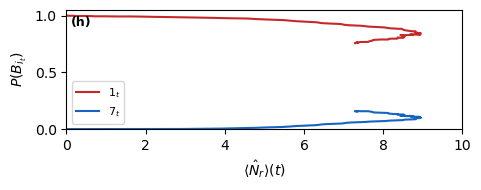

In [10]:
# reload past simulation data
data_pos = load_data("/home/yz0814/fig3h_data.npz") # replace with your path
plot_fig3h(data_pos, Nr_max=10, t_cut=154)